# Data Visualization using Matplotlib
## Lab 5 — Air Quality Index (AQI)

### Aim
To visualize AQI trends and pollutant levels using **Matplotlib**.

### Dataset note
`sklearn.datasets` does not provide a dedicated real-world AQI dataset. Therefore, this lab creates a **simple AQI-style dataset using `sklearn.datasets.make_regression`** and transforms it into pollutant values such as PM2.5, PM10 and CO.

This keeps the lab fully based on the sklearn library while making the visualization easy to understand.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression

# Create sample data using sklearn
X, y = make_regression(
    n_samples=30,
    n_features=3,
    random_state=42
)

# Convert the generated values into simple pollutant ranges
df = pd.DataFrame(X, columns=["PM25_raw", "PM10_raw", "CO_raw"])

df["Date"] = pd.date_range("2025-01-01", periods=30)

df["PM25"] = (df["PM25_raw"] - df["PM25_raw"].min()) / (
    df["PM25_raw"].max() - df["PM25_raw"].min()
) * 150 + 20

df["PM10"] = (df["PM10_raw"] - df["PM10_raw"].min()) / (
    df["PM10_raw"].max() - df["PM10_raw"].min()
) * 200 + 30

df["CO"] = (df["CO_raw"] - df["CO_raw"].min()) / (
    df["CO_raw"].max() - df["CO_raw"].min()
) * 10 + 1

# Create a simple AQI value from pollutant levels
df["AQI"] = (
    0.45 * df["PM25"] +
    0.35 * df["PM10"] +
    5 * df["CO"]
)

df["AQI"] = df["AQI"].round(2)

# Keep only the columns needed for the lab
df = df[["Date", "PM25", "PM10", "CO", "AQI"]]

# Save the dataset
df.to_csv("City_Air_Quality.csv", index=False)

print("Dataset created successfully.")
display(df.head())


Dataset created successfully.


,Date,PM25,PM10,CO,AQI
0,2025-01-01,127.559080,111.010927,8.789638,140.20
1,2025-01-02,61.171827,107.866309,5.392011,92.24
2,2025-01-03,170.000000,69.711970,7.117339,136.49
3,2025-01-04,106.065419,225.951390,5.566368,154.64
4,2025-01-05,70.468070,39.980163,8.318296,87.30


## 1. Explore the dataset

In [2]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

print("\nBasic statistics:")
display(df.describe())


Dataset shape: (30, 5)

Column names:
['Date', 'PM25', 'PM10', 'CO', 'AQI']

Data types:
Date    datetime64[us]
PM25           float64
PM10           float64
CO             float64
AQI            float64
dtype: object

First 5 rows:


,Date,PM25,PM10,CO,AQI
0,2025-01-01,127.559080,111.010927,8.789638,140.20
1,2025-01-02,61.171827,107.866309,5.392011,92.24
2,2025-01-03,170.000000,69.711970,7.117339,136.49
3,2025-01-04,106.065419,225.951390,5.566368,154.64
4,2025-01-05,70.468070,39.980163,8.318296,87.30



Basic statistics:


,Date,PM25,PM10,CO,AQI
count,30,30.000000,30.000000,30.000000,30.000000
mean,2025-01-15 12:00:00,108.315514,114.933084,5.897314,118.455000
min,2025-01-01 00:00:00,20.000000,30.000000,1.000000,76.270000
25%,2025-01-08 06:00:00,77.008386,76.003518,4.658088,96.967500
50%,2025-01-15 12:00:00,106.326347,112.314660,5.754375,118.045000
75%,2025-01-22 18:00:00,135.692192,141.690911,8.155914,139.190000
max,2025-01-30 00:00:00,170.000000,230.000000,11.000000,165.280000
std,NaN,37.505241,50.441225,2.730826,23.756602


## 2. Identify variables for visualization

- **Date** → time
- **PM25** → PM2.5 pollutant level
- **PM10** → PM10 pollutant level
- **CO** → carbon monoxide level
- **AQI** → overall air quality index


## 3. Line plot — Overall AQI trend

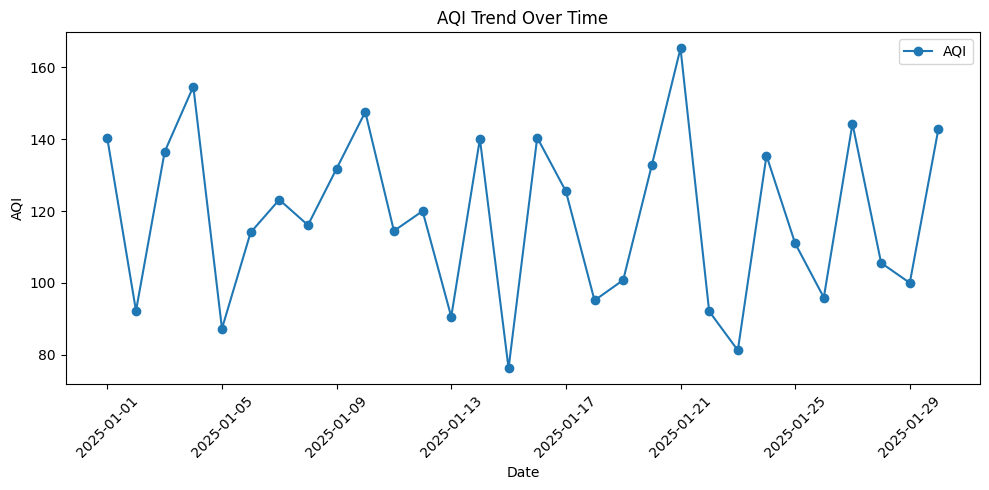

In [3]:
plt.figure(figsize=(10, 5))

plt.plot(df["Date"], df["AQI"], marker="o", label="AQI")

plt.title("AQI Trend Over Time")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


## 4. Line plots — Individual pollutants

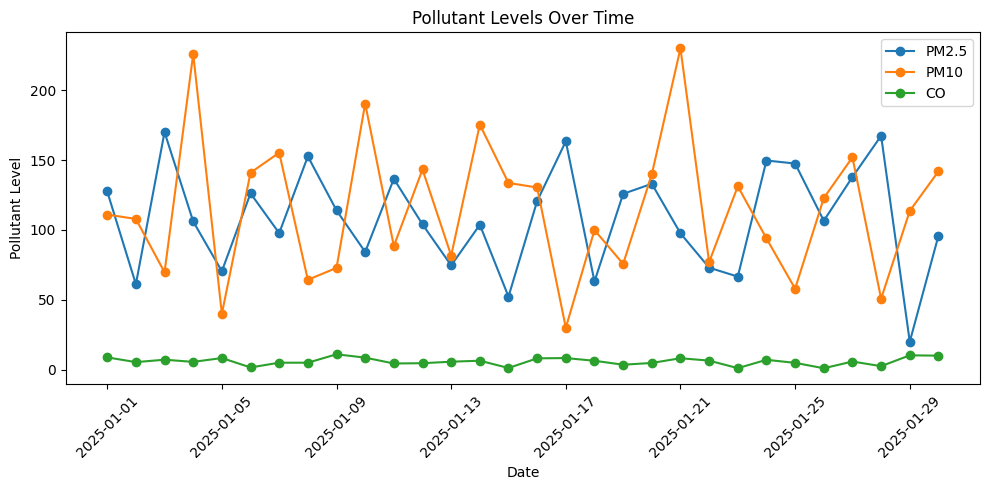

In [4]:
plt.figure(figsize=(10, 5))

plt.plot(df["Date"], df["PM25"], marker="o", label="PM2.5")
plt.plot(df["Date"], df["PM10"], marker="o", label="PM10")
plt.plot(df["Date"], df["CO"], marker="o", label="CO")

plt.title("Pollutant Levels Over Time")
plt.xlabel("Date")
plt.ylabel("Pollutant Level")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


## 5. Bar plot — AQI values

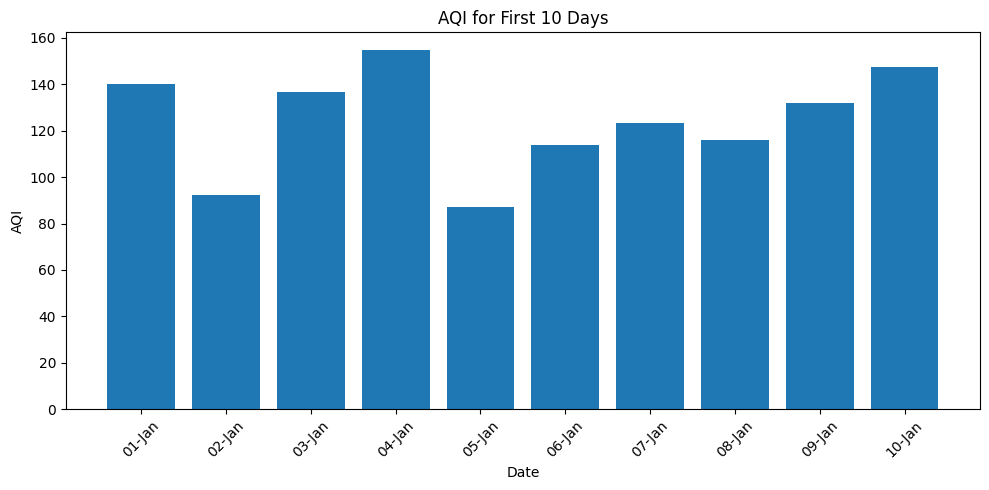

In [5]:
# Show AQI for the first 10 days
sample = df.head(10)

plt.figure(figsize=(10, 5))
plt.bar(sample["Date"].dt.strftime("%d-%b"), sample["AQI"])

plt.title("AQI for First 10 Days")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 6. Box plot — Distribution of pollutants

C:\Users\parth\AppData\Local\Temp\ipykernel_8260\4097271317.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


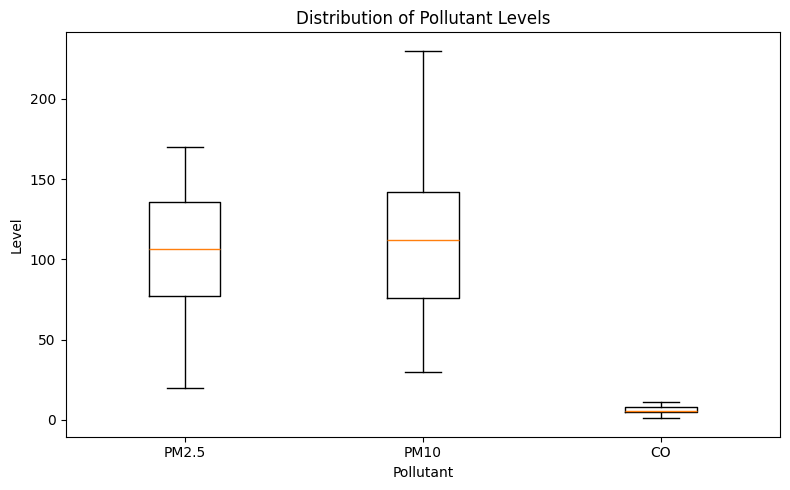

In [6]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [df["PM25"], df["PM10"], df["CO"]],
    labels=["PM2.5", "PM10", "CO"]
)

plt.title("Distribution of Pollutant Levels")
plt.xlabel("Pollutant")
plt.ylabel("Level")
plt.tight_layout()
plt.show()


## 7. Scatter plot — AQI and PM2.5

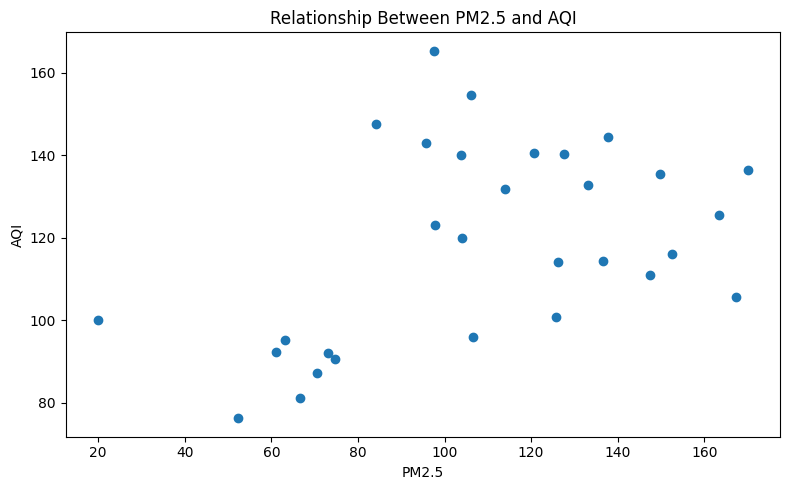

In [7]:
plt.figure(figsize=(8, 5))

plt.scatter(df["PM25"], df["AQI"])

plt.title("Relationship Between PM2.5 and AQI")
plt.xlabel("PM2.5")
plt.ylabel("AQI")
plt.tight_layout()
plt.show()


## 8. Scatter plot — AQI and PM10

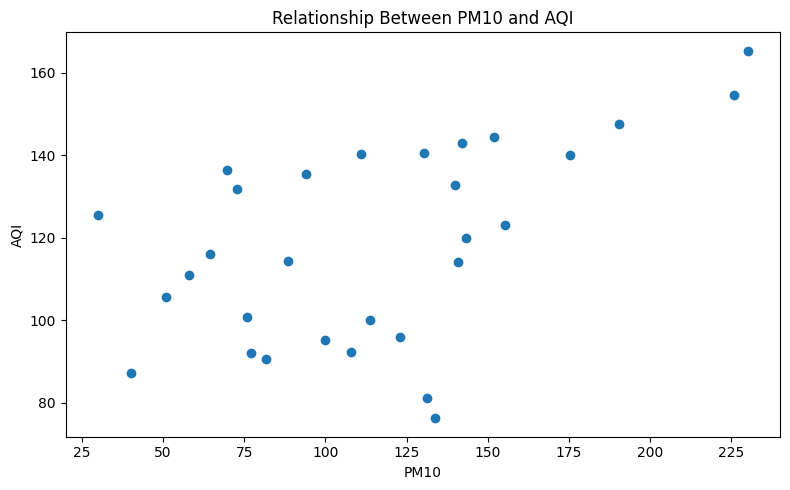

In [8]:
plt.figure(figsize=(8, 5))

plt.scatter(df["PM10"], df["AQI"])

plt.title("Relationship Between PM10 and AQI")
plt.xlabel("PM10")
plt.ylabel("AQI")
plt.tight_layout()
plt.show()


## 9. Add labels and find the highest AQI

Highest AQI:
Date    2025-01-21 00:00:00
PM25              97.575167
PM10                  230.0
CO                 8.174774
AQI                  165.28
Name: 20, dtype: object


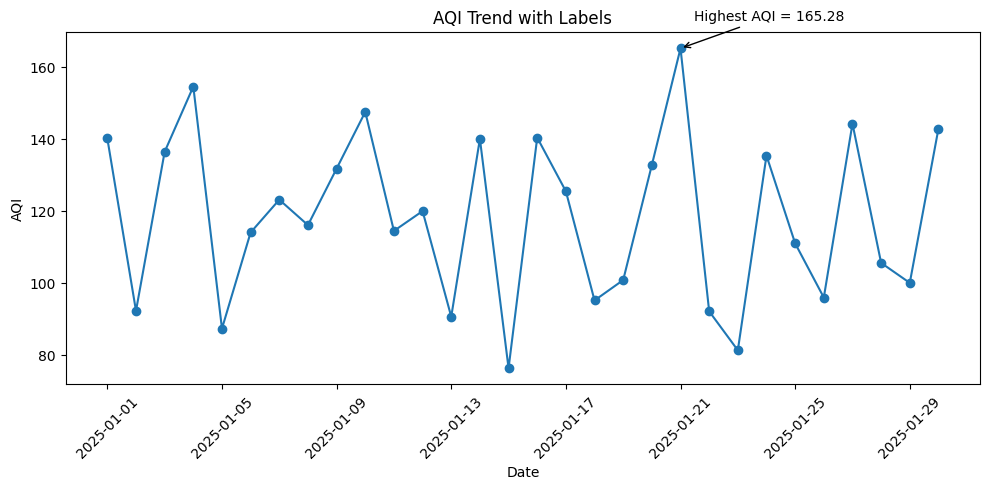

In [9]:
highest_aqi = df.loc[df["AQI"].idxmax()]

print("Highest AQI:")
print(highest_aqi)

plt.figure(figsize=(10, 5))

plt.plot(df["Date"], df["AQI"], marker="o")

plt.title("AQI Trend with Labels")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.xticks(rotation=45)

# Mark the highest AQI
plt.annotate(
    f"Highest AQI = {highest_aqi['AQI']}",
    xy=(highest_aqi["Date"], highest_aqi["AQI"]),
    xytext=(10, 20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.tight_layout()
plt.show()


## Conclusion

The AQI-style dataset was visualized using Matplotlib.

The following plots were created:
- Line plot for AQI trend
- Line plot for pollutant levels
- Bar plot for AQI comparison
- Box plot for pollutant distribution
- Scatter plots for AQI and pollutant relationships

Labels, titles, legends and axis names were also added to make the graphs easy to understand.
